In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import bilby
import shutil
import corner
import pickle

In [2]:
# update with your path
stochastic_lite_path='/Users/andrewmatas/Desktop/projects/stochastic_lite' 

import sys
sys.path.insert(0,'%s/src'%stochastic_lite_path)
from constants import *
from cross_correlation import *
from postprocessing import *
from pe import *
from util import *

In [3]:
# settings for plotting
matplotlib.rcParams.update({'font.size':15})

In [4]:
# random seed
seed=0
np.random.seed(seed)

# Parameters

In [5]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = 1.0 # strain
sigma_inj_min=0
sigma_inj_max=0.9*sigma
sigma_inj         =  np.random.uniform(low=sigma_inj_min,high=sigma_inj_max) # Should draw from a distribution bounded between 0 and something less than sigma
print(sigma_inj)
NSegments         = 16
Fs                = 16 #32. # Hz
segmentDuration   = 256.0 # s
TsegCoarseGrained = 32.0 #2.0 # s
betaMin=-3
betaMax=3

beta1_N = betaMin
beta2_N = betaMax
beta_S =  np.random.uniform(low=betaMin,high=betaMax) # Should draw from a uniform distribution from [beta1_N,beta2N]
print(beta_S)

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFCoarseGrained = 1/TsegCoarseGrained
#fref=fNyquist/2.
fref=1

0.4939321535345923
1.2911361982345166


In [6]:
# Parameters for injection

noise_params={'fref':fref,'amp':2*sigma**2*deltaT,'beta1':beta1_N,'beta2':beta2_N}
signal_params={'fref':fref,'amp':2*sigma_inj**2*deltaT,'beta':beta_S}
loudest_signal_params={'fref':fref,'amp':2*sigma**2*deltaT,'beta':0}
fullDuration=NSegments*segmentDuration
N=int(fullDuration/deltaT)
deltaF_full = 1/(fullDuration)

In [7]:
# Spectra for injections

def UShape_psd(freqs,params):
    fref=params['fref']
    amp=params['amp']
    beta1=params['beta1']
    beta2=params['beta2']
    
    psd=amp * ((freqs/fref)**(beta1) + (freqs/fref)**(beta2))
    
    return psd

def powerLaw(freqs,params):
    fref=params['fref']
    amp=params['amp']
    beta=params['beta']
    
    PL=amp * (freqs/fref)**beta
    
    return PL
    

In [8]:
fullDuration*deltaFCoarseGrained

128.0

In [9]:
np.sqrt(2*fullDuration*deltaFCoarseGrained)

16.0

In [10]:
freqs=np.arange(deltaFCoarseGrained,fNyquist,deltaFCoarseGrained)
P1 =  UShape_psd(freqs,params=noise_params)
P2 =  UShape_psd(freqs,params=noise_params)
Ph =  powerLaw(freqs,params=signal_params)
#rho_expected = np.sqrt(2*(fullDuration-segmentDuration)*deltaFCoarseGrained*np.sum(Ph**2/(P1*P2)))
rho_expected = np.sqrt((fullDuration-segmentDuration)*deltaFCoarseGrained*np.sum(Ph**2/(P1*P2)))
#rho_expected = np.sqrt(2*segmentDuration*deltaFCoarseGrained*np.sum(Ph**2/(P1*P2)))
print(rho_expected)

8.618724081935556


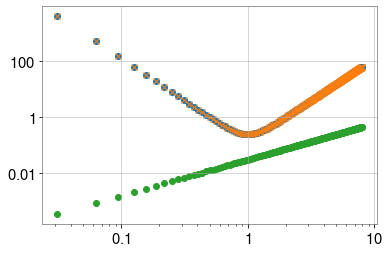

In [11]:
plt.loglog(freqs,P1,'o')
plt.loglog(freqs,P2,'x')
plt.loglog(freqs,Ph,'o')

# Generate colored noise and signal

In [12]:
def generateTimeSeriesFromSpectrum(duration, deltaT, spectrum, params=None):
    
    '''
    simulate time series from a given spectrum(f)
    
    params = array
    
    fref should be <= fNyq = 1/(2*deltaT)
    '''
    N=int(duration/deltaT)
    
    # check fref
    if fref > 1/(2*deltaT):
        print('error in powerLaw(): fref greater than fNyquist')
        return
    
    # determine discrete frequencies
    if np.mod(N,2) == 0:
        numFreqs = int(N/2 - 1)
    else:
        numFreqs = int((N-1)/2)

    T = N*deltaT   
    assert T==duration
    
    deltaF = 1/T
    f = deltaF*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
    
    # generate ASD in frequency domain (random phases)
    PSD = spectrum(f,params=params)
    norm = np.sqrt(N/(2*deltaT)) * np.sqrt(PSD)
    
    x = norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
    y = norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
    z = x + 1j*y
    
    if np.mod(N,2)==0:
        # note that most negative frequency is -f_Nyquist when N=even 
        temp1 = np.append(np.array([0]), z)
        temp2 = np.append(np.array([0]), np.flipud(np.conj(z)))
        dtilde = np.append(temp1, temp2)
    else:
        # no Nyquist frequency when N=odd
        temp1 = np.append(np.array([0]), z)
        dtilde = np.append(temp1, np.flipud(np.conj(z))) 
    
    # fourier transform back to time domai
    d = np.fft.ifft(dtilde)
    d = np.real(d) # imag part = 0 to round off
    
    t = deltaT*np.arange(0, N, 1)
    
    return d, t


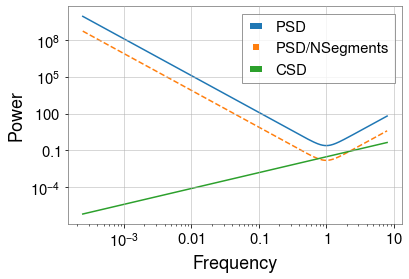

In [13]:
A=noise_params['amp']
fref=noise_params['fref']
beta1=noise_params['beta1']
beta2=noise_params['beta2']
if np.mod(N,2) == 0:
    numFreqs = int(N/2 - 1)
else:
    numFreqs = int((N-1)/2)
freqs = deltaF_full*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
psd = A * ((freqs/fref)**beta1 +(freqs/fref)**(beta2) )

plt.loglog(freqs,psd,label='PSD')
plt.loglog(freqs,psd/NSegments,linestyle='--',label='PSD/NSegments')

A=signal_params['amp']
fref=signal_params['fref']
alpha=signal_params['beta']
if np.mod(N,2) == 0:
    numFreqs = int(N/2 - 1)
else:
    numFreqs = int((N-1)/2)
freqs = deltaF_full*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
csd = A * ((freqs/fref)**alpha )

plt.loglog(freqs,csd,label='CSD')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.legend()

In [14]:
# Generate injection

noise1,t=generateTimeSeriesFromSpectrum(fullDuration, 
                                      deltaT, 
                                      UShape_psd, 
                                      params=noise_params)

noise2,t=generateTimeSeriesFromSpectrum(fullDuration, 
                                      deltaT, 
                                      UShape_psd, 
                                      params=noise_params)

signal,t=generateTimeSeriesFromSpectrum(fullDuration, 
                                      deltaT, 
                                      powerLaw, 
                                      params=signal_params)

d1=noise1+signal
d2=noise2+signal

In [15]:
deltaFCoarseGrained*segmentDuration

8.0

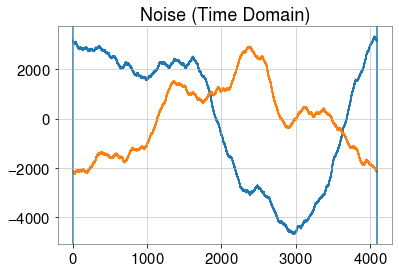

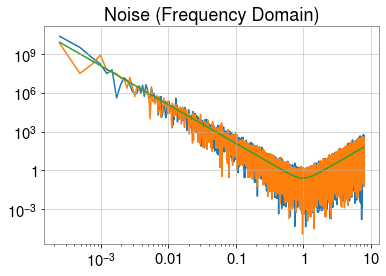

In [16]:
# Check noise injection

plt.plot(t,noise1)
plt.plot(t,noise2)
plt.axvline(0)
plt.axvline(fullDuration)
plt.title('Noise (Time Domain)')
plt.show()
plt.clf()

dtilde1=np.fft.rfft(noise1)[1:-1]*deltaT
dtilde2=np.fft.rfft(noise2)[1:-1]*deltaT

A=noise_params['amp']
fref=noise_params['fref']
alpha=noise_params['beta1']
if np.mod(N,2) == 0:
    numFreqs = int(N/2 - 1)
else:
    numFreqs = int((N-1)/2)
freqs = deltaF_full*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
psd = A * ((freqs/fref)**alpha +(freqs/fref)**(-alpha) )
plt.loglog(freqs,np.abs(dtilde1)**2 * 2 *deltaF_full)
plt.loglog(freqs,np.abs(dtilde2)**2 * 2 *deltaF_full)
plt.loglog(freqs,psd)
plt.title('Noise (Frequency Domain)')

plt.show()

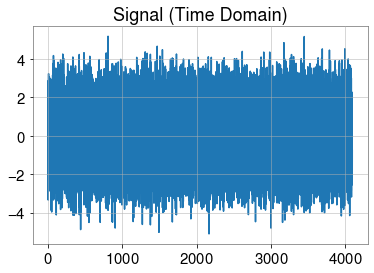

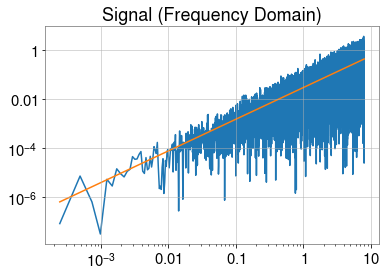

In [17]:
# Check signal injection

plt.plot(t,signal)
plt.title('Signal (Time Domain)')
plt.show()
plt.clf()

dtilde=np.fft.rfft(signal)[1:-1]*deltaT

A=signal_params['amp']
fref=signal_params['fref']
alpha=signal_params['beta']
if np.mod(N,2) == 0:
    numFreqs = int(N/2 - 1)
else:
    numFreqs = int((N-1)/2)
freqs = deltaF_full*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
csd = A * ((freqs/fref)**alpha )
plt.loglog(freqs,np.abs(dtilde)**2 * 2 *deltaF_full)
plt.loglog(freqs,csd)
plt.title('Signal (Frequency Domain)')

plt.show()

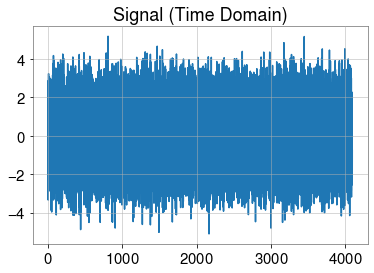

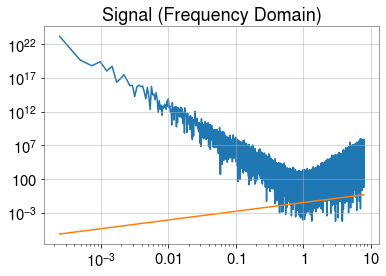

In [18]:
# Check signal injection

plt.plot(t,signal)
plt.title('Signal (Time Domain)')
plt.show()
plt.clf()

d1tilde=np.fft.rfft(d1)[1:-1]*deltaT
d2tilde=np.fft.rfft(d2)[1:-1]*deltaT

d12tilde=np.real(np.conj(d1tilde)*d2tilde)

A=signal_params['amp']
fref=signal_params['fref']
alpha=signal_params['beta']
if np.mod(N,2) == 0:
    numFreqs = int(N/2 - 1)
else:
    numFreqs = int((N-1)/2)
freqs = deltaF_full*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
csd = A * ((freqs/fref)**alpha )
plt.loglog(freqs,np.abs(d12tilde)**2 * 2 *deltaF_full)
plt.loglog(freqs,csd)
plt.title('Signal (Frequency Domain)')

plt.show()

# Run stochastic lite

In [19]:
d1_TS=TimeSeries(t,d1)
d2_TS=TimeSeries(t,d2)

In [20]:
# cross correlation analysis

Ys,sigs,Y_ft,var_ft,segmentStartTimes,freqsS=cross_correlation(d1_TS,
                                                               d2_TS,
                                                               segmentDuration,
                                                               deltaFCoarseGrained,
                                                               verbose=True,
                                                               doOverlap=True,
                                                               alpha=0,
                                                               fref=fref,
                                                               orf_file=None,
                                                               fmin=deltaFCoarseGrained,
                                                               fmax=fNyquist-deltaFCoarseGrained)

stochastic: Done with Interval 1 / 27
	Y     = 3.645730e+32
	sigma = 2.876209e+34
	SNR   = 0.012675
stochastic: Done with Interval 2 / 27
	Y     = 3.946358e+34
	sigma = 2.888163e+34
	SNR   = 1.366390
stochastic: Done with Interval 3 / 27
	Y     = 3.678921e+34
	sigma = 2.941310e+34
	SNR   = 1.250776
stochastic: Done with Interval 4 / 27
	Y     = -1.111723e+33
	sigma = 2.981441e+34
	SNR   = -0.037288
stochastic: Done with Interval 5 / 27
	Y     = 3.874541e+34
	sigma = 2.872011e+34
	SNR   = 1.349069
stochastic: Done with Interval 6 / 27
	Y     = 1.238217e+34
	sigma = 2.787186e+34
	SNR   = 0.444253
stochastic: Done with Interval 7 / 27
	Y     = 5.845556e+33
	sigma = 2.894009e+34
	SNR   = 0.201988
stochastic: Done with Interval 8 / 27
	Y     = 1.624929e+34
	sigma = 2.787692e+34
	SNR   = 0.582894
stochastic: Done with Interval 9 / 27
	Y     = -1.450198e+34
	sigma = 2.769347e+34
	SNR   = -0.523661
stochastic: Done with Interval 10 / 27
	Y     = 3.451503e+34
	sigma = 2.698072e+34
	SNR   = 1.27

/Users/andrewmatas/Desktop/projects/stochastic_lite/src/cross_correlation.py:138: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data,var_f.data)
/Users/andrewmatas/Desktop/projects/stochastic_lite/src/cross_correlation.py:139: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_ft[:,II],var_ft[:,II] = Y_f.data, var_f.data


In [21]:
# Post processing

jobDuration = NSegments*segmentDuration
Y_f,var_f=postprocessing_spectra(Y_ft,var_ft,jobDuration,segmentDuration,deltaFCoarseGrained,deltaT,bufferSecs=0)

In [22]:
alpha = beta_S + 3
H = (freqsS/fref)**alpha

var = 1/np.sum((var_f/H**2)**(-1))
sig = np.sqrt(var)
ptEst = np.sum( (Y_f/H) / (var_f/H**2) ) * var

print('alpha = %f'%alpha)
print('Y = %e +/- %e'%(ptEst,sig))
print('Optimal SNR=%f'%(ptEst/sig))

Sh=2*sigma_inj**2*deltaT
expectedY = (fref)**3 * (10*np.pi**2)/(3*H0**2) * Sh #* fref**alpha
print('Expected Y = %e'%expectedY)

alpha = 4.291136
Y = 8.594591e+34 +/- 9.281875e+33
Optimal SNR=9.259542
Expected Y = 9.552657e+34


In [23]:
print(ptEst/expectedY)

0.8997068795894693


In [24]:
1/(2*deltaT)

8.0

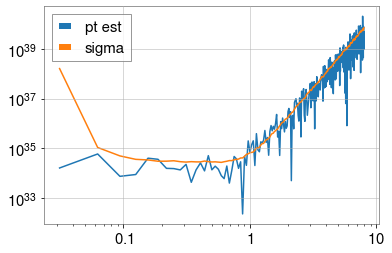

In [25]:
# Sanity check spectra

plt.loglog(freqsS,np.abs(Y_f),label='pt est')
plt.loglog(freqsS,np.sqrt(var_f),label='sigma')
plt.legend()

In [26]:
# Compare to injection


# conversion between Omega and Sh
def Omega_to_Sh(Omega,freqs,fref=25):
    Sh =  (3*H0**2/(10*np.pi**2)) * Omega / (fref)**3 * (freqs/fref)**(-3)
    return Sh


def beta_to_alpha(beta):
    return beta+3
def alpha_to_beta(alpha):
    return alpha-3

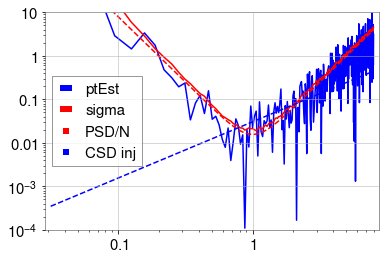

In [27]:
Sh_ptEst=Omega_to_Sh(Y_f,freqsS,fref=fref)
Sh_sigma=Omega_to_Sh(np.sqrt(var_f),freqsS,fref=fref)

plt.loglog(freqsS,np.abs(Sh_ptEst),label='ptEst',color='blue')
plt.loglog(freqsS,np.abs(Sh_sigma),label='sigma',color='red')
freqs=np.arange(deltaFCoarseGrained,fNyquist,deltaFCoarseGrained)
psd = (2*sigma**2*deltaT) * ((freqs/fref)**beta1_N +(freqs/fref)**(beta2_N) )
plt.loglog(freqs,psd/NSegments,linestyle='--',label='PSD/N',color='red')
csd = (2*sigma_inj**2*deltaT) * ((freqs/fref)**beta_S )
plt.loglog(freqs,csd,linestyle='--',label='CSD inj',color='blue')
plt.xlim(0.9*deltaFCoarseGrained,1.1*fNyquist)
plt.ylim(1e-4,1e1)
plt.legend()

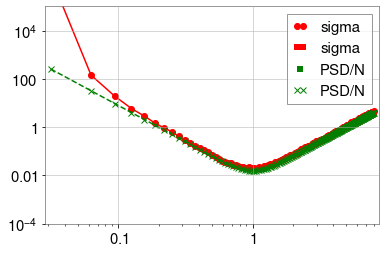

In [28]:
Sh_sigma=Omega_to_Sh(np.sqrt(var_f),freqsS,fref=fref)

plt.loglog(freqsS,np.abs(Sh_sigma),'o',label='sigma',color='red')
plt.loglog(freqsS,np.abs(Sh_sigma),label='sigma',color='red')
freqs=np.arange(deltaFCoarseGrained,fNyquist,deltaFCoarseGrained)
psd = (2*sigma**2*deltaT) * ((freqs/fref)**(beta1_N) +(freqs/fref)**(beta2_N) )
plt.loglog(freqs,psd/NSegments,linestyle='--',label='PSD/N',color='green')
plt.loglog(freqs,psd/NSegments,'x',label='PSD/N',color='green')



plt.xlim(0.9*deltaFCoarseGrained,1.1*fNyquist)
plt.ylim(1e-4,1e5)
plt.legend()

In [29]:
fref

1

(0, 2)

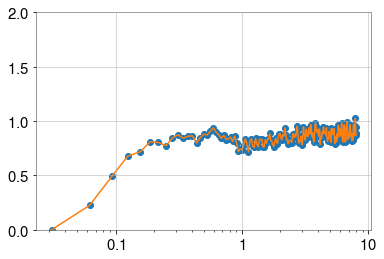

In [30]:
plt.semilogx(freqs,psd/NSegments/np.abs(Sh_sigma),'o')
plt.semilogx(freqs,psd/NSegments/np.abs(Sh_sigma))
plt.ylim(0,2)

4.3434343434343425
4.291136198234517


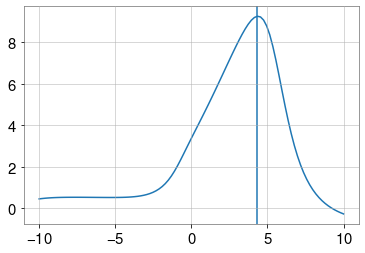

In [31]:
Nalphas=100
alphas=np.linspace(-10,10,Nalphas)
sigs=np.zeros(Nalphas)
ptEsts=np.zeros(Nalphas)

for ii,alphaGW in enumerate(alphas):
    Hf = (freqsS/fref)**alphaGW
    var = 1/np.sum((var_f/Hf**2)**(-1))
    sigs[ii] = np.sqrt(var)
    ptEsts[ii] = np.sum((Y_f/Hf) / (var_f/Hf**2)) * var

snrs=ptEsts/sigs
plt.plot(alphas,snrs)
plt.axvline(beta_S+3)

imax=np.argmax(snrs)
print(alphas[imax])
print(beta_S+3)

# PE

14:50 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:50 bilby INFO    : Search parameters:
14:50 bilby INFO    :   A = Uniform(minimum=0.0, maximum=3.171572277080261e+36, name='A', latex_label='A', unit=None, boundary=None)
14:50 bilby INFO    :   alpha = Uniform(minimum=0, maximum=6, name='alpha', latex_label='alpha', unit=None, boundary=None)
14:50 bilby INFO    : Single likelihood evaluation took 1.396e-04 s


0it [00:00, ?it/s]

14:50 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 500, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 300, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7fa215114650>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
14:50 bilby INFO    : Checkpoint every n_check_point = 4000000
14:50 bilby INFO    : Using dynesty version 1.0.1
14:50 bilby INFO    : Using the bilby-implemented rwalk samp

4885it [00:39, 87.99it/s, bound:468 nc:50 ncall:167719 eff:2.9% logz-ratio=35.44+/-0.16 dlogz:0.101>0.10]  

14:50 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



4889it [00:40, 120.78it/s, bound:469 nc:1 ncall:167920 eff:3.2% logz-ratio=35.53+/-0.16 dlogz:0.000>0.10]



14:50 bilby INFO    : Sampling time: 0:00:39.474407
14:50 bilby INFO    : Summary of results:
nsamples: 5389
log_noise_evidence: -22410.902
log_evidence: -22375.370 +/-  0.160
log_bayes_factor: 35.532 +/-  0.160



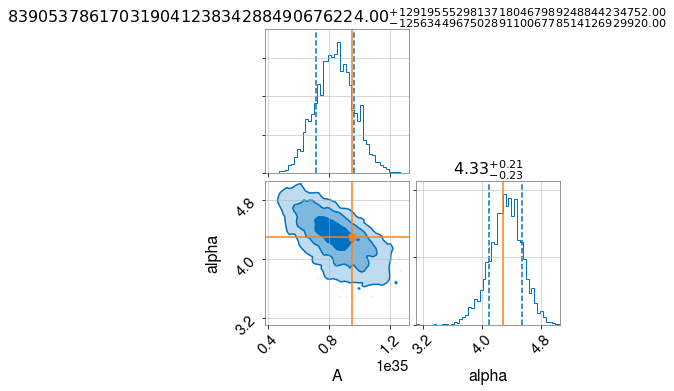

In [32]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)


injection_parameters=dict(A=2*deltaT*sigma_inj**2 * (fref)**3 * (10*np.pi**2)/(3*H0**2),
                         alpha=beta_S+3)

# Sh = 1 / (2*deltaT) * (3*H0**2/(10*np.pi**2)) * A / (fref)**3
# A = (2*deltaT) * (fref)**3 * (10*np.pi**2)/(3*H0**2) * Sh 

Sh_min = 2*deltaT*sigma_inj_min**2
Sh_max = 10*2*deltaT*sigma_inj_max**2
Amin = (fref)**3 * (10*np.pi**2)/(3*H0**2) * Sh_min
Amax = (fref)**3 * (10*np.pi**2)/(3*H0**2) * Sh_max
alpha_min=beta_to_alpha(betaMin)
alpha_max=beta_to_alpha(betaMax)


fref=fref

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],
                                        var_f[1:],
                                        #var_theor*(freqs[1:]/15)**6,
                                        freqsS[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result_Yf = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000,
    injection_parameters=injection_parameters)
result_Yf.plot_corner()

# OLD

Keeping it to see what I did wrong in generating colored noise

In [33]:
# don't want to evaluate cells below here when doing restart and run all
raise Exception

Exception: 

In [ ]:
NSegments=16

data_time_series=np.zeros((len(times),NSegments,2))
data_frequency_series=np.zeros((len(freqs),NSegments,2))*1j

tAll=np.arange(0,segmentDuration*NSegments,deltaT)
deltaFAll=1/(tAll[-1]-tAll[0]+deltaT)
freqsAll=np.arange(deltaFAll,fNyquist+epsilon,deltaFAll)

psd=2*sigma**2*deltaT*((freqsAll/fref)**(beta_noise))# + (freqsAll/fref)**(-beta_noise))
csd=2*sigma_inj**2*deltaT*(freqsAll/fref)**(beta_GW)

# Generate n1(t)
fft_amp = (np.sqrt(psd) / np.sqrt(2)) / np.sqrt(deltaFAll) 
fft_arg = np.random.uniform(size=len(freqsAll),low=0,high=2*np.pi)
fft_phase = np.exp(1j*fft_arg)
fft=fft_amp*fft_phase
fft=np.append(fft,fft[0]) # need to put on Nyquist frequency so FFT has len 2^N+1, then IFFT has len 2^(N-1)
n1=np.fft.irfft(fft)* deltaFAll  * (len(freqsAll)*2) 
    
# Generate n2(t)
fft_amp = (np.sqrt(psd) / np.sqrt(2)) / np.sqrt(deltaFAll) 
fft_arg = np.random.uniform(size=len(freqsAll),low=0,high=2*np.pi)
fft_phase = np.exp(1j*fft_arg)
fft=fft_amp*fft_phase
fft=np.append(fft,fft[0]) # need to put on Nyquist frequency so FFT has len 2^N+1, then IFFT has len 2^(N-1)
n2=np.fft.irfft(fft) * deltaFAll  * (len(freqsAll)*2) 
    
# Generate h(t)
fft_amp = (np.sqrt(csd) / np.sqrt(2)) / np.sqrt(deltaFAll) 
fft_arg = np.random.uniform(size=len(freqsAll),low=0,high=2*np.pi)
fft_phase = np.exp(1j*fft_arg)
fft=fft_amp*fft_phase
fft=np.append(fft,fft[0]) # need to put on Nyquist frequency so FFT has len 2^N+1, then IFFT has len 2^(N-1)
h=np.fft.irfft(fft)  * deltaFAll * (len(freqsAll)*2)
    
# Construct detector time series
d1 = n1+h
d2 = n2+h
   
data_time_series=np.zeros((int(len(tAll)/NSegments),NSegments,2))
for I in range(NSegments):
    data_time_series[:,I,0]=d1[int(I*segmentDuration*Fs) : int((I+1)*segmentDuration*Fs)]
    data_time_series[:,I,1]=d2[int(I*segmentDuration*Fs) : int((I+1)*segmentDuration*Fs)]
    
    # Construct detector frequency series
    data_frequency_series[:,I,0]=np.fft.rfft(data_time_series[:,I,0])[:-1]*deltaT
    data_frequency_series[:,I,1]=np.fft.rfft(data_time_series[:,I,1])[:-1]*deltaT
    